# Amazon Video Games — BERTopic Topic Modeling

目標：從評論文字中萃取主題，找出哪些主題的商品排名更好。

流程：
1. 篩選高品質評論（helpful_vote ≥ 1）並抽樣
2. 跑 BERTopic 找出主題
3. 視覺化主題分佈
4. 分析各主題與商品排名的關係
5. 輸出商品層級的主題特徵（供後續預測模型使用）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path().resolve().parent
PROCESSED  = ROOT / 'data' / 'processed'
OUTPUT_DIR = ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print('套件載入完成')

套件載入完成


In [2]:
# 讀取評論
reviews = pd.read_csv(PROCESSED / 'reviews_clean.csv', parse_dates=['date'])
meta    = pd.read_csv(PROCESSED / 'meta_clean.csv')

# 清理負值
reviews = reviews[reviews['helpful_vote'] >= 0]

print(f'總評論數：{len(reviews):,}')

總評論數：3,670,126


## 1. 篩選高品質評論並抽樣

In [3]:
# 只用 helpful_vote >= 1 的評論（品質較高）
# 再加上最低字數門檻（至少 10 個字）
quality_reviews = reviews[
    (reviews['helpful_vote'] >= 1) &
    (reviews['text_length'] >= 10)
].copy()

print(f'高品質評論數：{len(quality_reviews):,}')
print(f'涵蓋商品數：{quality_reviews["parent_asin"].nunique():,}')

# 如果超過 10 萬則就抽樣，加快速度
MAX_DOCS = 100000
if len(quality_reviews) > MAX_DOCS:
    sample_reviews = quality_reviews.sample(MAX_DOCS, random_state=42)
    print(f'抽樣至 {MAX_DOCS:,} 則')
else:
    sample_reviews = quality_reviews
    print('全部使用，不需抽樣')

docs = sample_reviews['text'].tolist()
print(f'BERTopic 輸入文件數：{len(docs):,}')

高品質評論數：835,227
涵蓋商品數：50,661
抽樣至 100,000 則
BERTopic 輸入文件數：100,000


## 2. 跑 BERTopic

⚠️ 這個 cell 第一次跑需要下載模型（約 500MB），需要幾分鐘。
跑完之後會自動儲存模型，下次跑就快很多。

In [4]:
MODEL_PATH = ROOT / 'data' / 'processed' / 'bertopic_model'

if MODEL_PATH.exists():
    print('載入已儲存的模型...')
    topic_model = BERTopic.load(str(MODEL_PATH))
    topics, probs = topic_model.transform(docs)
    print('模型載入完成')
else:
    print('開始訓練 BERTopic 模型（請耐心等候）...')

    # 設定 vectorizer：移除常見停用字
    vectorizer = CountVectorizer(
        stop_words='english',
        min_df=10,
        ngram_range=(1, 2)
    )

    topic_model = BERTopic(
        vectorizer_model=vectorizer,
        nr_topics=50,          # 最多 50 個主題
        min_topic_size=100,    # 每個主題至少 100 則評論
        verbose=True
    )

    topics, probs = topic_model.fit_transform(docs)

    # 儲存模型
    topic_model.save(str(MODEL_PATH))
    print(f'模型已儲存至 {MODEL_PATH}')

topic_info = topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outliers = topic_info[topic_info['Topic'] == -1]['Count'].values[0]

print(f'\n找到主題數：{n_topics}')
print(f'未分類評論數（Topic -1）：{n_outliers:,}')
print('\n前 10 個主題：')
print(topic_info.head(11).to_string())

2026-06-03 01:06:40,775 - BERTopic - Embedding - Transforming documents to embeddings.


開始訓練 BERTopic 模型（請耐心等候）...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

2026-06-03 01:20:26,309 - BERTopic - Embedding - Completed ✓
2026-06-03 01:20:26,310 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-03 01:21:08,715 - BERTopic - Dimensionality - Completed ✓
2026-06-03 01:21:08,719 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-03 01:21:18,210 - BERTopic - Cluster - Completed ✓
2026-06-03 01:21:18,211 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-03 01:21:36,339 - BERTopic - Representation - Completed ✓
2026-06-03 01:21:36,353 - BERTopic - Topic reduction - Reducing number of topics
2026-06-03 01:21:36,435 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-03 01:21:53,565 - BERTopic - Representation - Completed ✓
2026-06-03 01:21:53,587 - BERTopic - Topic reduction - Reduced number of topics from 108 to 50
2026-06-03 01:21:55,780 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please mak

模型已儲存至 C:\Users\PC\Desktop\amazon-videogames-review-analysis\data\processed\bertopic_model

找到主題數：49
未分類評論數（Topic -1）：40,259

前 10 個主題：
    Topic  Count                                    Name                                                                             Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

## 3. 視覺化主題分佈

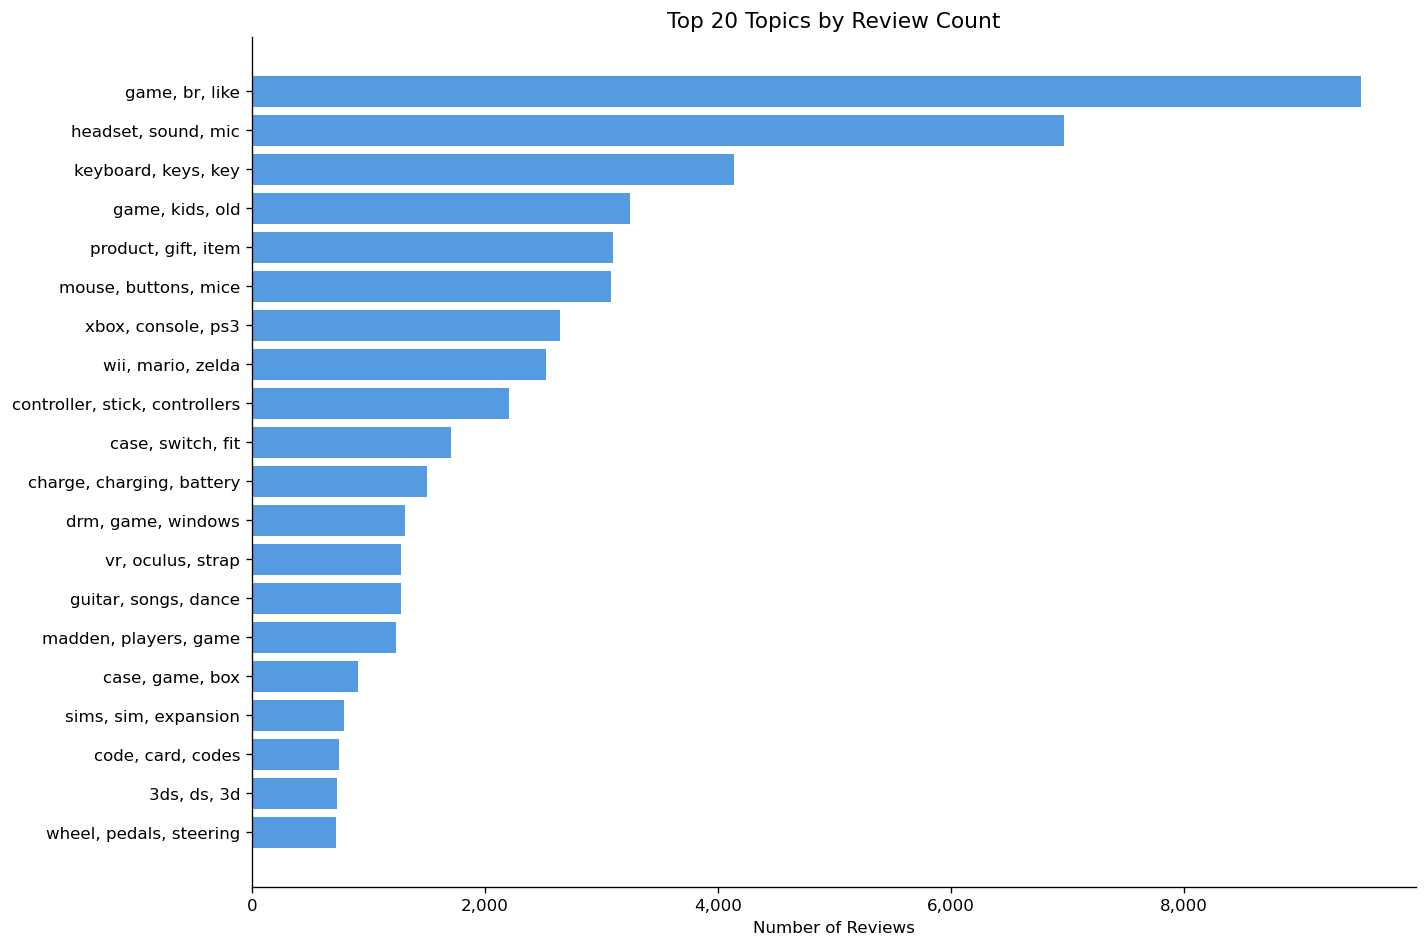

✅ 儲存：11_topic_distribution.png


In [5]:
# 取前 20 個最大主題（排除 -1）
top_topics = topic_info[topic_info['Topic'] != -1].head(20).copy()

# 取每個主題的前 3 個關鍵字作為標籤
def get_topic_label(topic_id):
    words = topic_model.get_topic(topic_id)
    if words:
        return ', '.join([w for w, _ in words[:3]])
    return f'Topic {topic_id}'

top_topics['label'] = top_topics['Topic'].apply(get_topic_label)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top_topics)), top_topics['Count'].values,
               color='#378ADD', edgecolor='none', alpha=0.85)
ax.set_yticks(range(len(top_topics)))
ax.set_yticklabels(top_topics['label'].values, fontsize=10)
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 20 Topics by Review Count', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_topic_distribution.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：11_topic_distribution.png')

各主題中位數排名（前10，排名越低越好）：
                                  label  count  avg_rank  avg_rating
44                stand, sturdy, stands    154   10639.0    4.136364
31                dock, switch, charger    380   11025.5    3.571053
39                    love, great, easy    268   11390.0    4.044776
5                  mouse, buttons, mice   3085   11406.0    3.389951
25  screen, protector, screen protector    477   11838.0    3.618449
34                          que, el, la    352   13030.5    4.105114
17                    code, card, codes    751   15267.0    2.724368
46      kingdom hearts, kingdom, hearts    120   16622.0    3.966667
19              wheel, pedals, steering    718   17025.0    3.725627
28                   fan, xbox, cooling    439   18602.0    3.282460


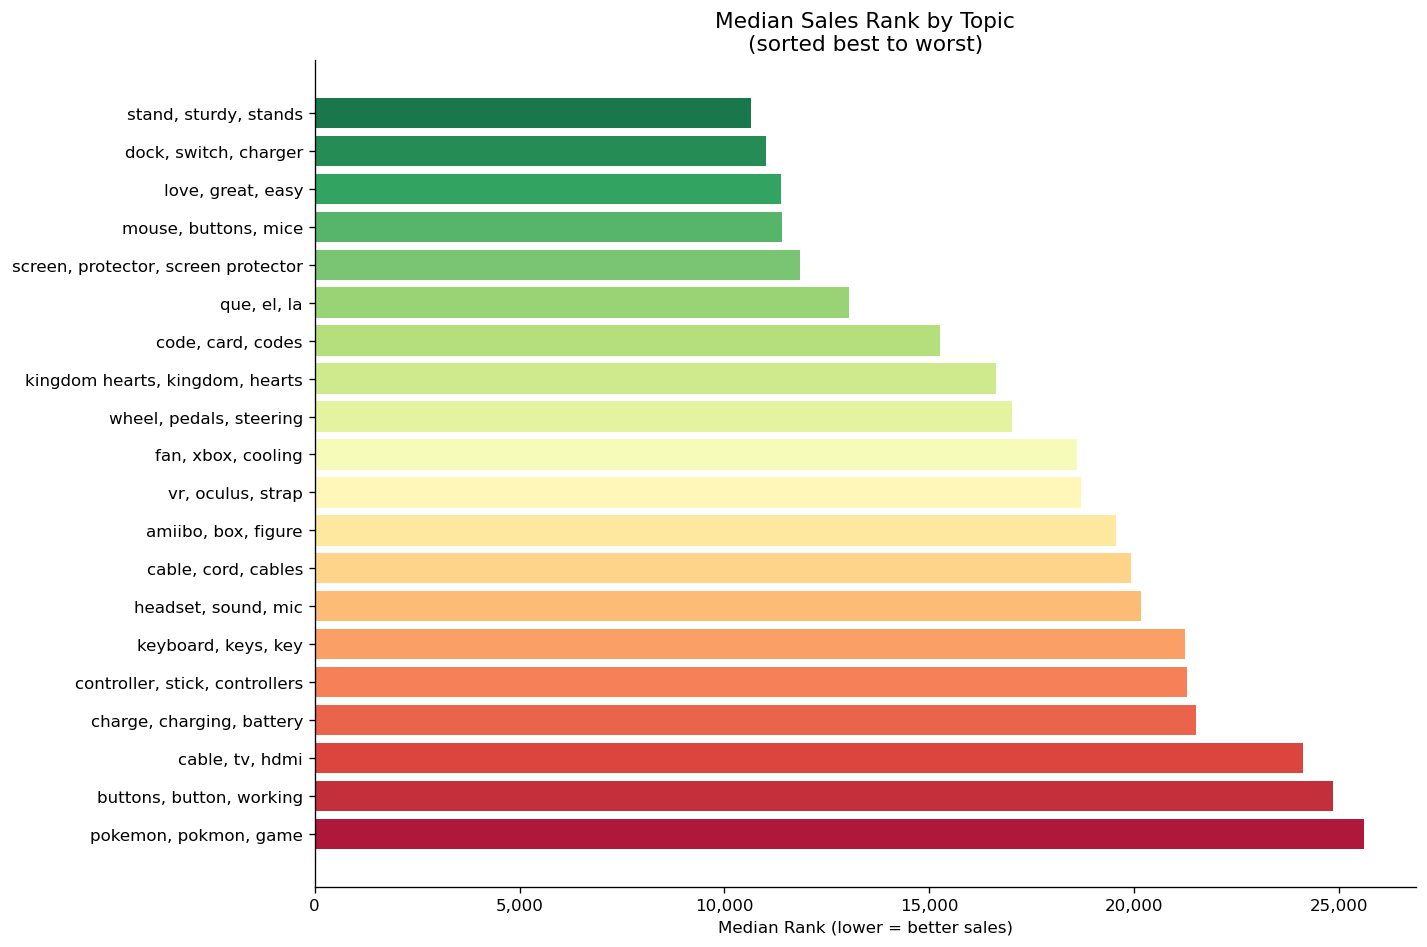

✅ 儲存：12_topic_vs_rank.png


In [ ]:
# 把主題標記加回評論
sample_reviews = sample_reviews.copy()
sample_reviews['topic'] = topics

# 合併排名資料
sample_reviews = sample_reviews.merge(
    meta[['parent_asin', 'log_rank', 'rank']],
    on='parent_asin', how='left'
)

# 各主題的平均排名（排除 -1 outlier）
topic_rank = (
    sample_reviews[sample_reviews['topic'] != -1]
    .groupby('topic')
    .agg(
        count    = ('rating', 'count'),
        avg_rank = ('rank', 'median'),
        avg_log_rank = ('log_rank', 'mean'),
        avg_rating   = ('rating', 'mean'),
    )
    .reset_index()
)

# 加上主題標籤
topic_rank['label'] = topic_rank['topic'].apply(get_topic_label)
topic_rank = topic_rank.sort_values('avg_rank')

print('各主題中位數排名（前10，排名越低越好）：')
print(topic_rank.head(10)[['label', 'count', 'avg_rank', 'avg_rating']].to_string())

# 視覺化：各主題的中位數排名
top20_by_rank = topic_rank.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors_rank = plt.cm.RdYlGn_r(
    np.linspace(0, 1, len(top20_by_rank))
)
bars = ax.barh(range(len(top20_by_rank)),
               top20_by_rank['avg_rank'].values,
               color=colors_rank, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(top20_by_rank)))
ax.set_yticklabels(top20_by_rank['label'].values, fontsize=10)
ax.set_xlabel('Median Rank (lower = better sales)')
ax.set_title('Median Sales Rank by Topic\n(sorted best to worst)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_topic_vs_rank.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：12_topic_vs_rank.png')

## 4. 各主題與商品排名的關係

各主題中位數排名（前10，排名越低越好）：
                                  label  count  avg_rank  avg_rating
44                stand, sturdy, stands    154   10639.0    4.136364
31                dock, switch, charger    380   11025.5    3.571053
39                    love, great, easy    268   11390.0    4.044776
5                  mouse, buttons, mice   3085   11406.0    3.389951
25  screen, protector, screen protector    477   11838.0    3.618449
34                          que, el, la    352   13030.5    4.105114
17                    code, card, codes    751   15267.0    2.724368
46      kingdom hearts, kingdom, hearts    120   16622.0    3.966667
19              wheel, pedals, steering    718   17025.0    3.725627
28                   fan, xbox, cooling    439   18602.0    3.282460


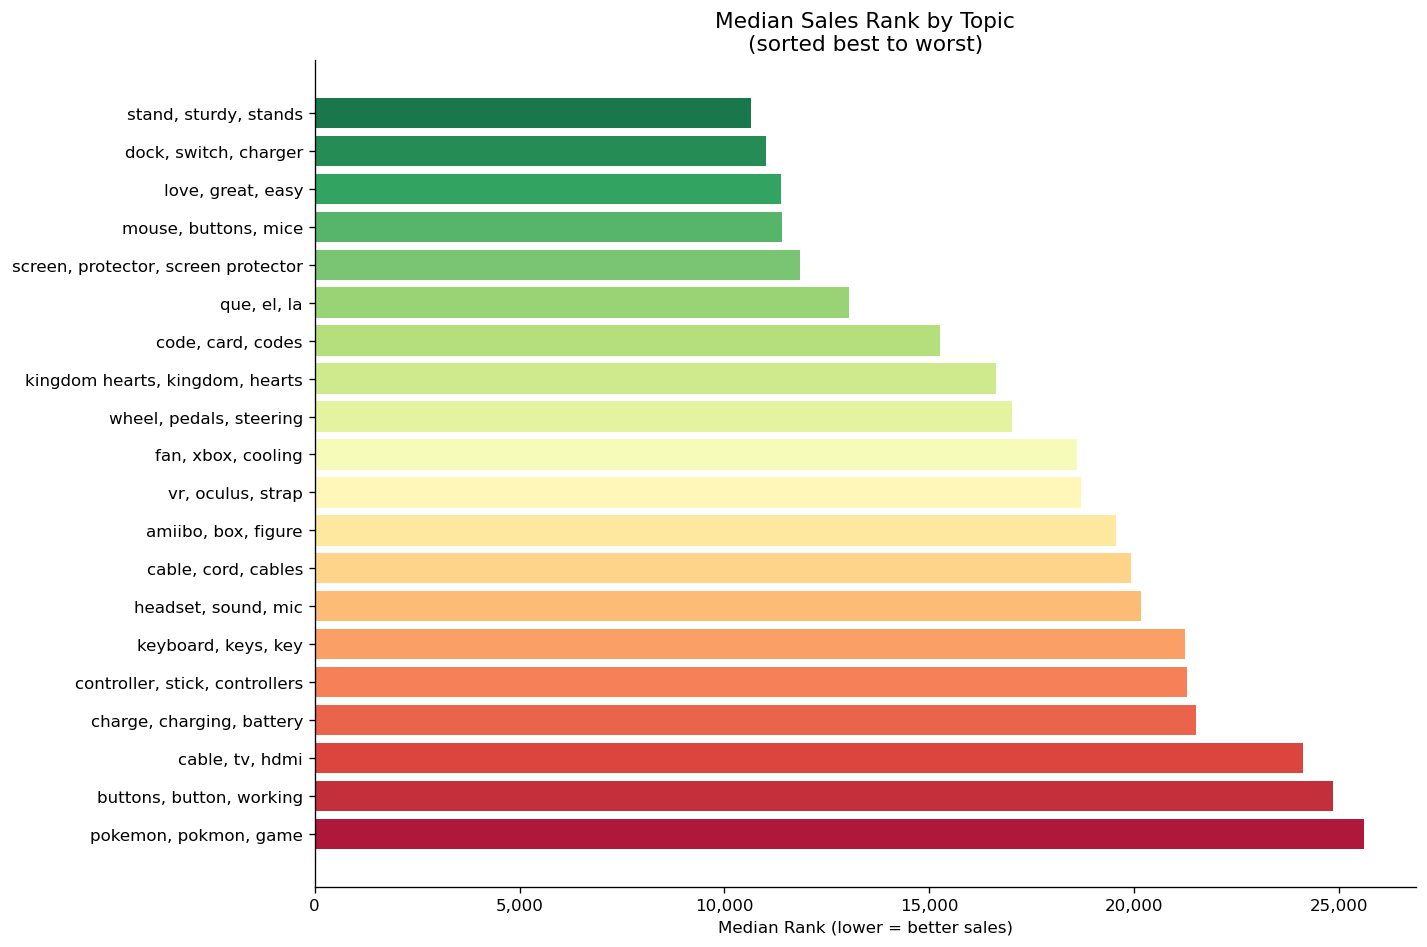

✅ 儲存：12_topic_vs_rank.png


In [6]:
# 把主題標記加回評論
sample_reviews = sample_reviews.copy()
sample_reviews['topic'] = topics

# 合併排名資料
sample_reviews = sample_reviews.merge(
    meta[['parent_asin', 'log_rank', 'rank']],
    on='parent_asin', how='left'
)

# 各主題的平均排名（排除 -1 outlier）
topic_rank = (
    sample_reviews[sample_reviews['topic'] != -1]
    .groupby('topic')
    .agg(
        count    = ('rating', 'count'),
        avg_rank = ('rank', 'median'),
        avg_log_rank = ('log_rank', 'mean'),
        avg_rating   = ('rating', 'mean'),
    )
    .reset_index()
)

# 加上主題標籤
topic_rank['label'] = topic_rank['topic'].apply(get_topic_label)
topic_rank = topic_rank.sort_values('avg_rank')

print('各主題中位數排名（前10，排名越低越好）：')
print(topic_rank.head(10)[['label', 'count', 'avg_rank', 'avg_rating']].to_string())

# 視覺化：各主題的中位數排名
top20_by_rank = topic_rank.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
colors_rank = plt.cm.RdYlGn_r(
    np.linspace(0, 1, len(top20_by_rank))
)
bars = ax.barh(range(len(top20_by_rank)),
               top20_by_rank['avg_rank'].values,
               color=colors_rank, edgecolor='none', alpha=0.9)
ax.set_yticks(range(len(top20_by_rank)))
ax.set_yticklabels(top20_by_rank['label'].values, fontsize=10)
ax.set_xlabel('Median Rank (lower = better sales)')
ax.set_title('Median Sales Rank by Topic\n(sorted best to worst)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_topic_vs_rank.png', bbox_inches='tight')
plt.show()
print('✅ 儲存：12_topic_vs_rank.png')

## 5. 輸出商品層級主題特徵

In [7]:
# 計算每個商品各主題的評論比例
# 這個特徵之後會丟進 XGBoost

valid_topics = sample_reviews[sample_reviews['topic'] != -1]

# 每個商品的主題分佈（pivot table）
product_topic = (
    valid_topics.groupby(['parent_asin', 'topic'])
    .size()
    .reset_index(name='count')
)

product_topic_pivot = product_topic.pivot(
    index='parent_asin',
    columns='topic',
    values='count'
).fillna(0)

# 轉成比例
product_topic_ratio = product_topic_pivot.div(
    product_topic_pivot.sum(axis=1), axis=0
)
product_topic_ratio.columns = [f'topic_{c}_ratio' for c in product_topic_ratio.columns]
product_topic_ratio = product_topic_ratio.reset_index()

# 合併排名
product_topic_ratio = product_topic_ratio.merge(
    meta[['parent_asin', 'log_rank', 'rank']],
    on='parent_asin', how='inner'
)

print(f'商品主題特徵表：{product_topic_ratio.shape[0]} 個商品 x {product_topic_ratio.shape[1]} 個欄位')

# 儲存
product_topic_ratio.to_csv(PROCESSED / 'product_topic_features.csv', index=False)
print('✅ 儲存：product_topic_features.csv')

商品主題特徵表：17024 個商品 x 52 個欄位
✅ 儲存：product_topic_features.csv
